In [1]:
import os, sys, random
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from PIL import Image
from torchvision import transforms

sys.path.append('/home/s5820023/Desktop/MC') 
sys.path.append('/home/s5820023/Desktop/MC/stage1_spillnet')
sys.path.append('/home/s5820023/Desktop/MC/stage3_mattingnet')
from model_spillnet  import SpillNet          
from model_mattingnet import MattingNet      
from postprocess     import despill_postprocess

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('ok')

ok


In [5]:
IMAGE_PATH = '/home/s5820023/Desktop/MC/dataset/image'
FG_PATH    = '/home/s5820023/Desktop/MC/dataset/fg'

CKPT_OLD = "/home/s5820023/Desktop/MC/checkpoints/stage1_spillnet/best.pth"
CKPT_NEW = "/home/s5820023/Desktop/MC/checkpoints/best_joint.pth"


INFER_SIZE = 512
to_tensor  = transforms.ToTensor()
print('ok')

ok


In [6]:
old_model = SpillNet(base=64).to(DEVICE)
old_model.load_state_dict(torch.load(CKPT_OLD, map_location=DEVICE))
old_model.eval()
print('ok')

ok


In [7]:
new_model = MattingNet(base=32).to(DEVICE)
new_model.load_state_dict(torch.load(CKPT_NEW, map_location=DEVICE))
new_model.eval()
print('ok')

ok


In [8]:
def predict_old(folder, filename):
    # stage1 needs gt alpha as input
    image   = to_tensor(Image.open(os.path.join(IMAGE_PATH, folder, filename)).convert('RGB'))
    fg_rgba = Image.open(os.path.join(FG_PATH, folder, filename)).convert('RGBA')
    fg_gt   = to_tensor(fg_rgba.convert('RGB'))
    alpha   = to_tensor(fg_rgba.split()[3])

    image_gpu = image.unsqueeze(0).to(DEVICE)
    alpha_gpu = alpha.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            pred = old_model(image_gpu, alpha_gpu)
        pred = despill_postprocess(pred.float(), alpha_gpu, strength=0.8)

    return (
        image.permute(1,2,0).numpy(),
        fg_gt.permute(1,2,0).numpy(),
        alpha.squeeze().numpy(),
        pred.squeeze().cpu().float().permute(1,2,0).numpy(),
    )


def predict_new(folder, filename):
    # stage3 only needs raw image
    image    = to_tensor(Image.open(os.path.join(IMAGE_PATH, folder, filename)).convert('RGB'))
    fg_rgba  = Image.open(os.path.join(FG_PATH, folder, filename)).convert('RGBA')
    fg_gt    = to_tensor(fg_rgba.convert('RGB'))
    alpha_gt = to_tensor(fg_rgba.split()[3])

    image_gpu = image.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            alpha_logit, alpha_pred, fg_pred = new_model(image_gpu)
        fg_pred = despill_postprocess(fg_pred.float(), alpha_pred, strength=0.8)

    return (
        image.permute(1,2,0).numpy(),
        fg_gt.permute(1,2,0).numpy(),
        alpha_gt.squeeze().numpy(),
        alpha_pred.squeeze().cpu().float().numpy(),
        fg_pred.squeeze().cpu().float().permute(1,2,0).numpy(),
    )

print('ok')


ok


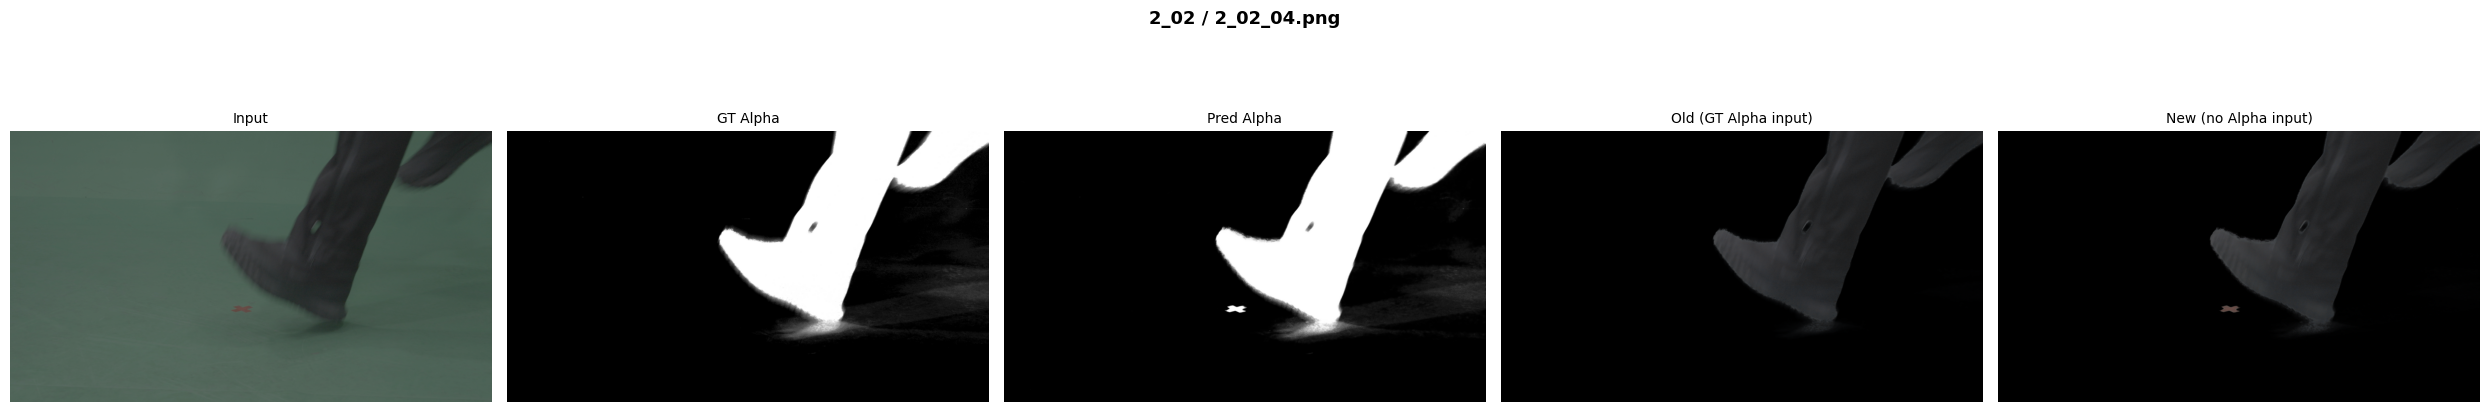

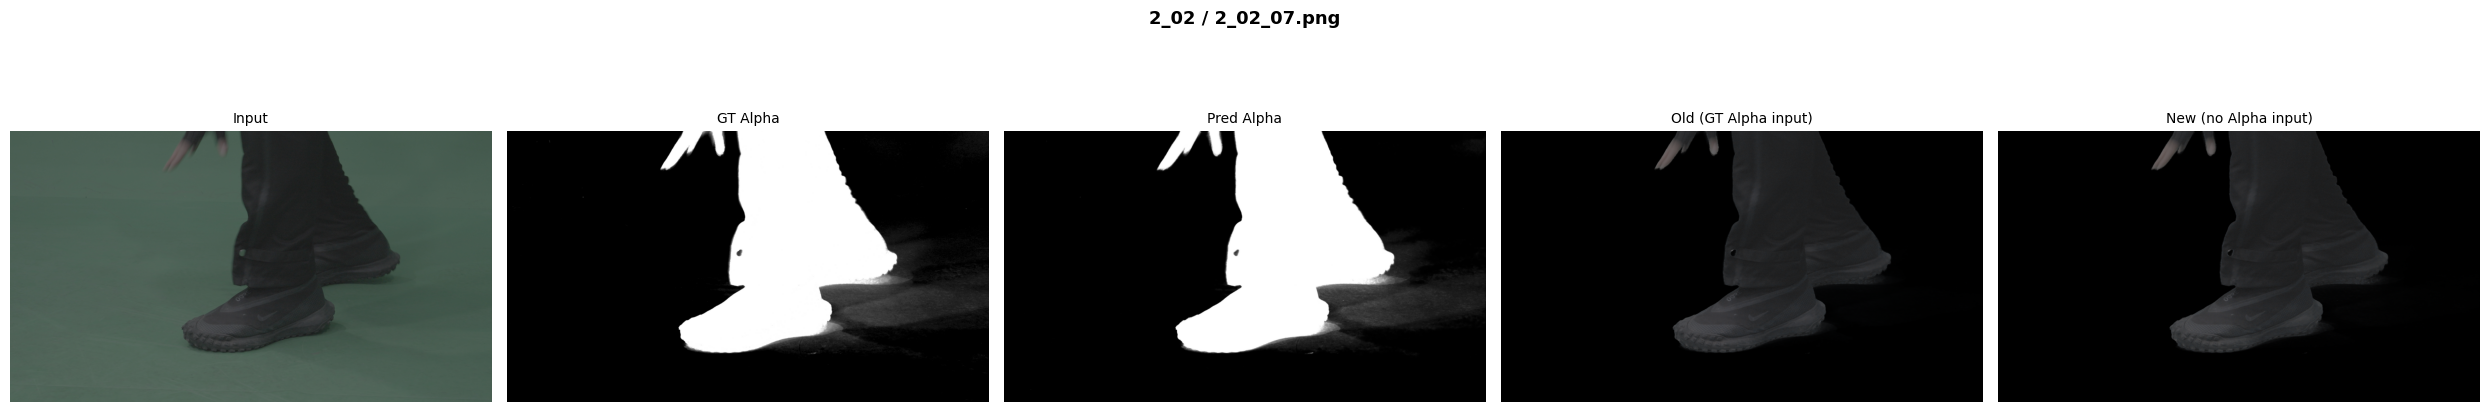

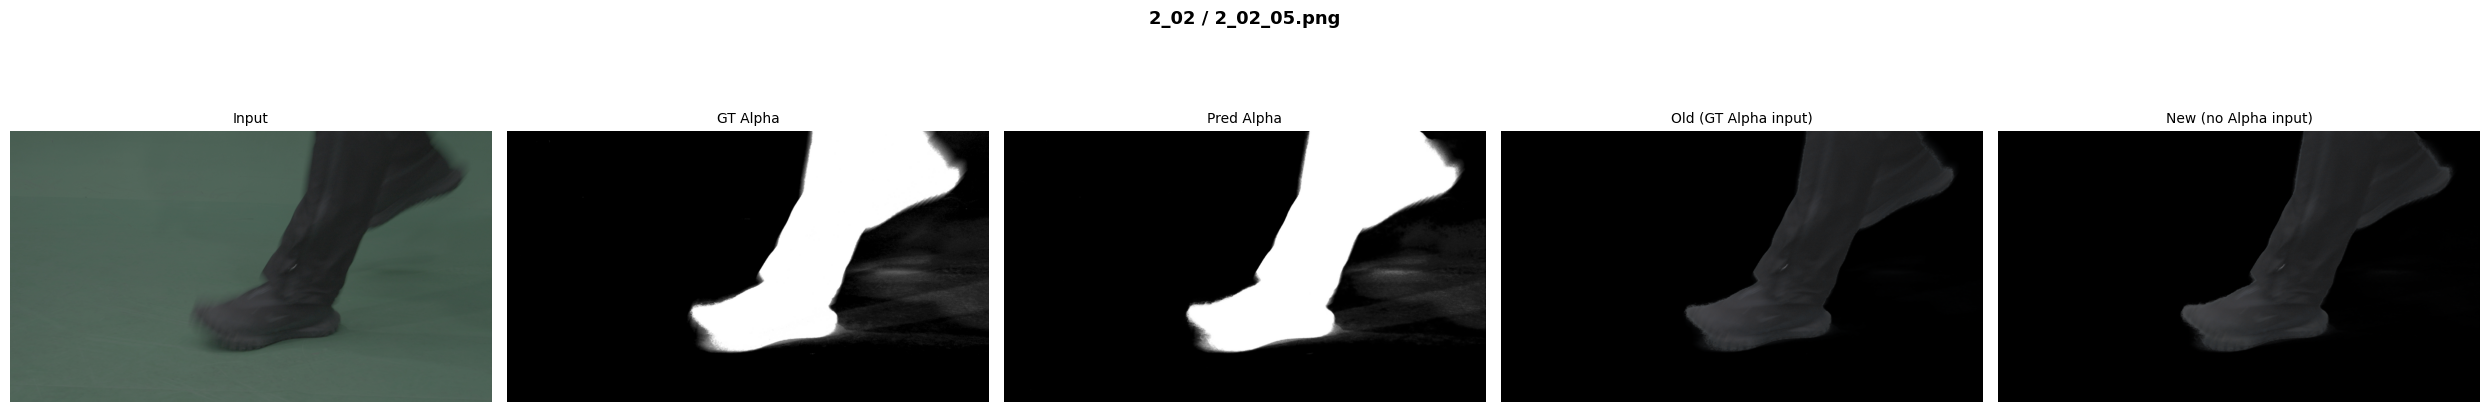

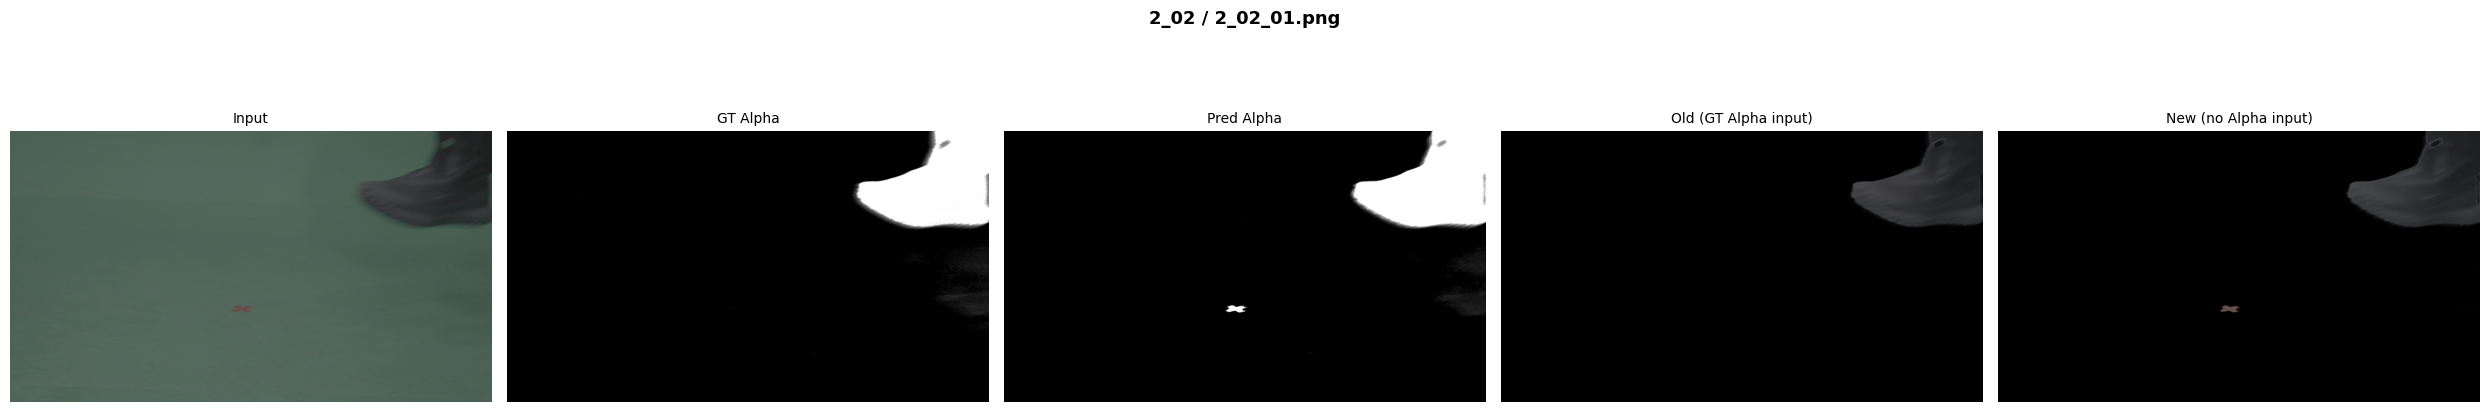

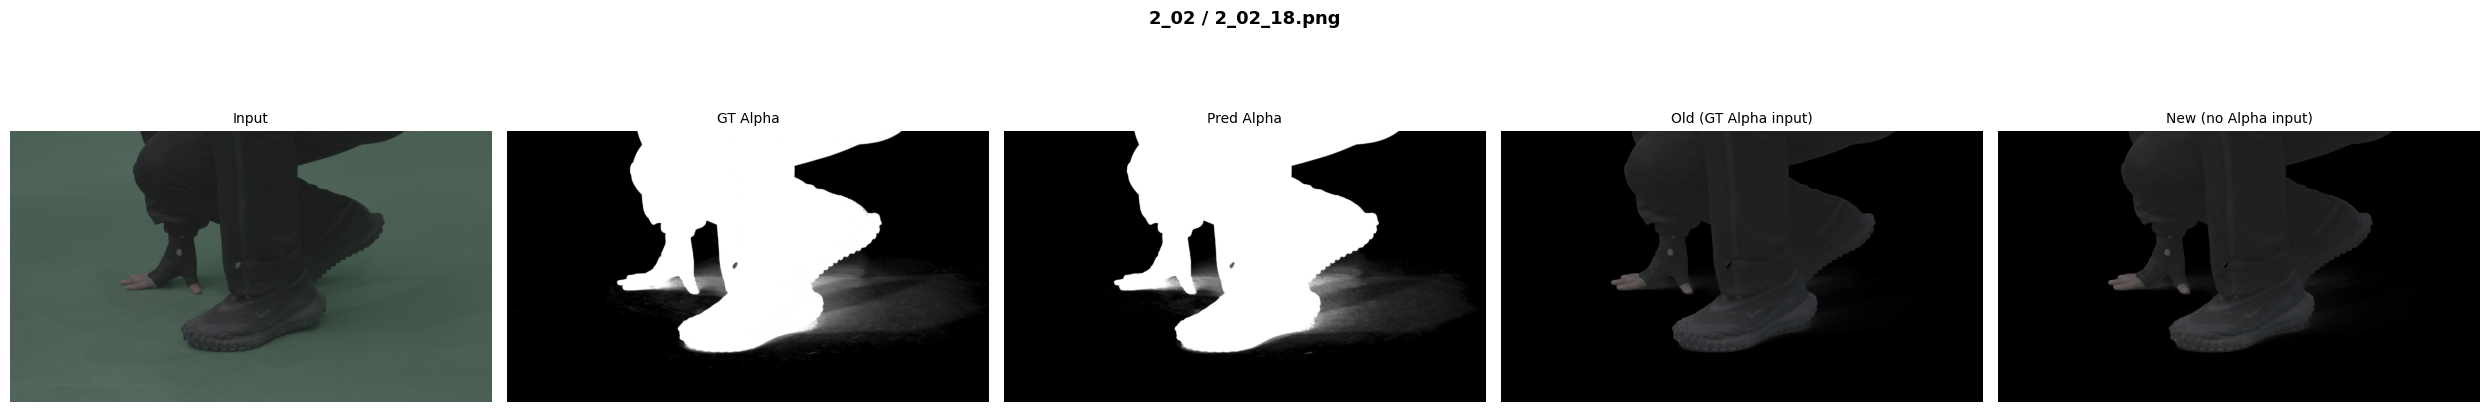

In [9]:
FOLDER     = '2_02'
all_frames = sorted(os.listdir(os.path.join(IMAGE_PATH, FOLDER)))
frames     = random.sample(all_frames, min(5, len(all_frames)))

for fname in frames:
    torch.cuda.empty_cache() 

    img_np, fg_gt_np, alpha_gt_np, alpha_pred_np, fg_pred_new_np = predict_new(FOLDER, fname)
    _,      _,        _,           fg_pred_old_np                 = predict_old(FOLDER, fname)

    a_gt_3ch   = alpha_gt_np[:, :, np.newaxis]
    a_pred_3ch = alpha_pred_np[:, :, np.newaxis]

    cols = [
        ('Input',                np.clip(img_np,                       0, 1), None),
        ('GT Alpha',             alpha_gt_np,                                 'gray'),
        ('Pred Alpha',           alpha_pred_np,                               'gray'),
        ('Old (GT Alpha input)', np.clip(fg_pred_old_np * a_gt_3ch,   0, 1), None),
        ('New (no Alpha input)', np.clip(fg_pred_new_np * a_pred_3ch, 0, 1), None),
    ]

    fig, axes = plt.subplots(1, 5, figsize=(25, 5))
    fig.suptitle(f'{FOLDER} / {fname}', fontsize=13, fontweight='bold')
    for ax, (title, data, cmap) in zip(axes, cols):
        ax.imshow(data, cmap=cmap)
        ax.set_title(title, fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

In [10]:
def compute_metrics(folder, n_samples=50):
    all_frames = sorted(os.listdir(os.path.join(IMAGE_PATH, folder)))
    samples    = random.sample(all_frames, min(n_samples, len(all_frames)))

    iou_list, mae_list = [], []

    for fname in samples:
        fg_rgba   = Image.open(os.path.join(FG_PATH, folder, fname)).convert('RGBA')
        alpha_gt  = to_tensor(fg_rgba.split()[3]).to(DEVICE)
        image_gpu = to_tensor(Image.open(os.path.join(IMAGE_PATH, folder, fname)).convert('RGB')).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            alpha_logit, alpha_pred, _ = new_model(image_gpu)

        alpha_pred = alpha_pred.squeeze()
        alpha_gt   = alpha_gt.squeeze()

        # MAE
        mae = (alpha_pred - alpha_gt).abs().mean().item()

        # IoU with threshold=0.5
        pred_bin = (alpha_pred > 0.5).float()
        gt_bin   = (alpha_gt   > 0.5).float()
        inter    = (pred_bin * gt_bin).sum().item()
        union    = (pred_bin + gt_bin - pred_bin * gt_bin).sum().item() + 1e-6
        iou      = inter / union

        iou_list.append(iou)
        mae_list.append(mae)

        torch.cuda.empty_cache()

    print(f'alpha metrics ({folder}, {len(samples)} frames)')
    print(f'  IoU : {np.mean(iou_list):.4f} +/- {np.std(iou_list):.4f}')
    print(f'  MAE : {np.mean(mae_list):.4f} +/- {np.std(mae_list):.4f}')
    return iou_list, mae_list

iou_list, mae_list = compute_metrics('2_02', n_samples=50)


alpha metrics (2_02, 23 frames)
  IoU : 0.9889 +/- 0.0067
  MAE : 0.0051 +/- 0.0005


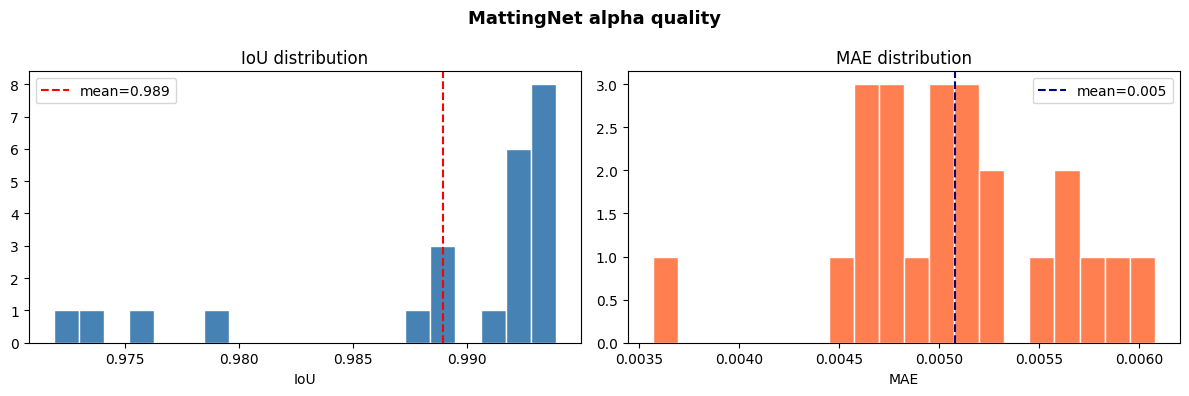

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('MattingNet alpha quality', fontsize=13, fontweight='bold')

axes[0].hist(iou_list, bins=20, color='steelblue', edgecolor='white')
axes[0].axvline(np.mean(iou_list), color='red', linestyle='--',
                label=f'mean={np.mean(iou_list):.3f}')
axes[0].set_title('IoU distribution')
axes[0].set_xlabel('IoU')
axes[0].legend()

axes[1].hist(mae_list, bins=20, color='coral', edgecolor='white')
axes[1].axvline(np.mean(mae_list), color='navy', linestyle='--',
                label=f'mean={np.mean(mae_list):.3f}')
axes[1].set_title('MAE distribution')
axes[1].set_xlabel('MAE')
axes[1].legend()

plt.tight_layout()
plt.show()

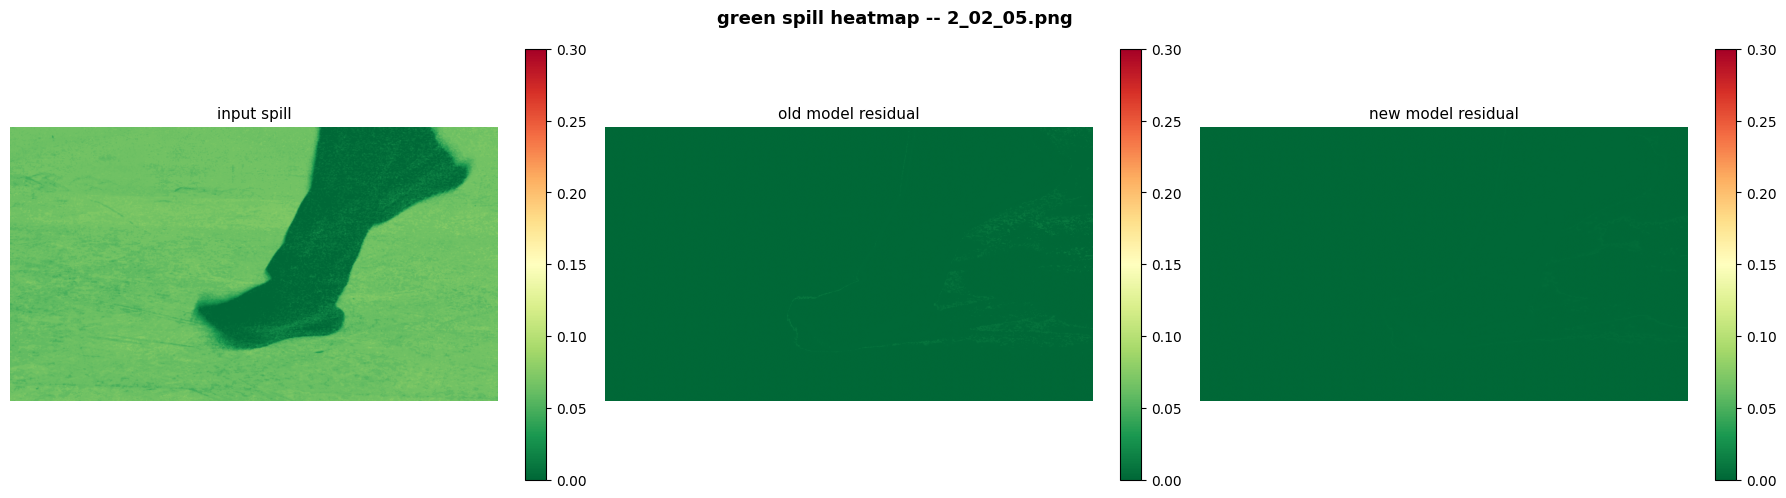

spill mean -> input: 0.0526 | old: 0.0002 | new: 0.0003


In [12]:
fname = random.choice(sorted(os.listdir(os.path.join(IMAGE_PATH, FOLDER))))

img_np, fg_gt_np, alpha_gt_np, fg_pred_old_np                 = predict_old(FOLDER, fname)
_,      _,        _,           alpha_pred_np, fg_pred_new_np   = predict_new(FOLDER, fname)

a_gt_3ch   = alpha_gt_np[:, :, np.newaxis]
a_pred_3ch = alpha_pred_np[:, :, np.newaxis]

def green_spill_map(rgb):
    # spill intensity = G - (R+B)/2  
    r, g, b = rgb[...,0], rgb[...,1], rgb[...,2]
    return np.clip(g - (r + b) / 2, 0, 1)

spill_input = green_spill_map(img_np)
spill_old   = green_spill_map(np.clip(fg_pred_old_np, 0, 1))
spill_new   = green_spill_map(np.clip(fg_pred_new_np, 0, 1))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'green spill heatmap -- {fname}', fontsize=13, fontweight='bold')

vmax = max(spill_input.max(), 0.3)
for ax, data, title in zip(axes,
    [spill_input, spill_old, spill_new],
    ['input spill', 'old model residual', 'new model residual']):
    im = ax.imshow(data, cmap='RdYlGn_r', vmin=0, vmax=vmax)
    ax.set_title(title, fontsize=11)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

print(f'spill mean -> input: {spill_input.mean():.4f} | old: {spill_old.mean():.4f} | new: {spill_new.mean():.4f}')

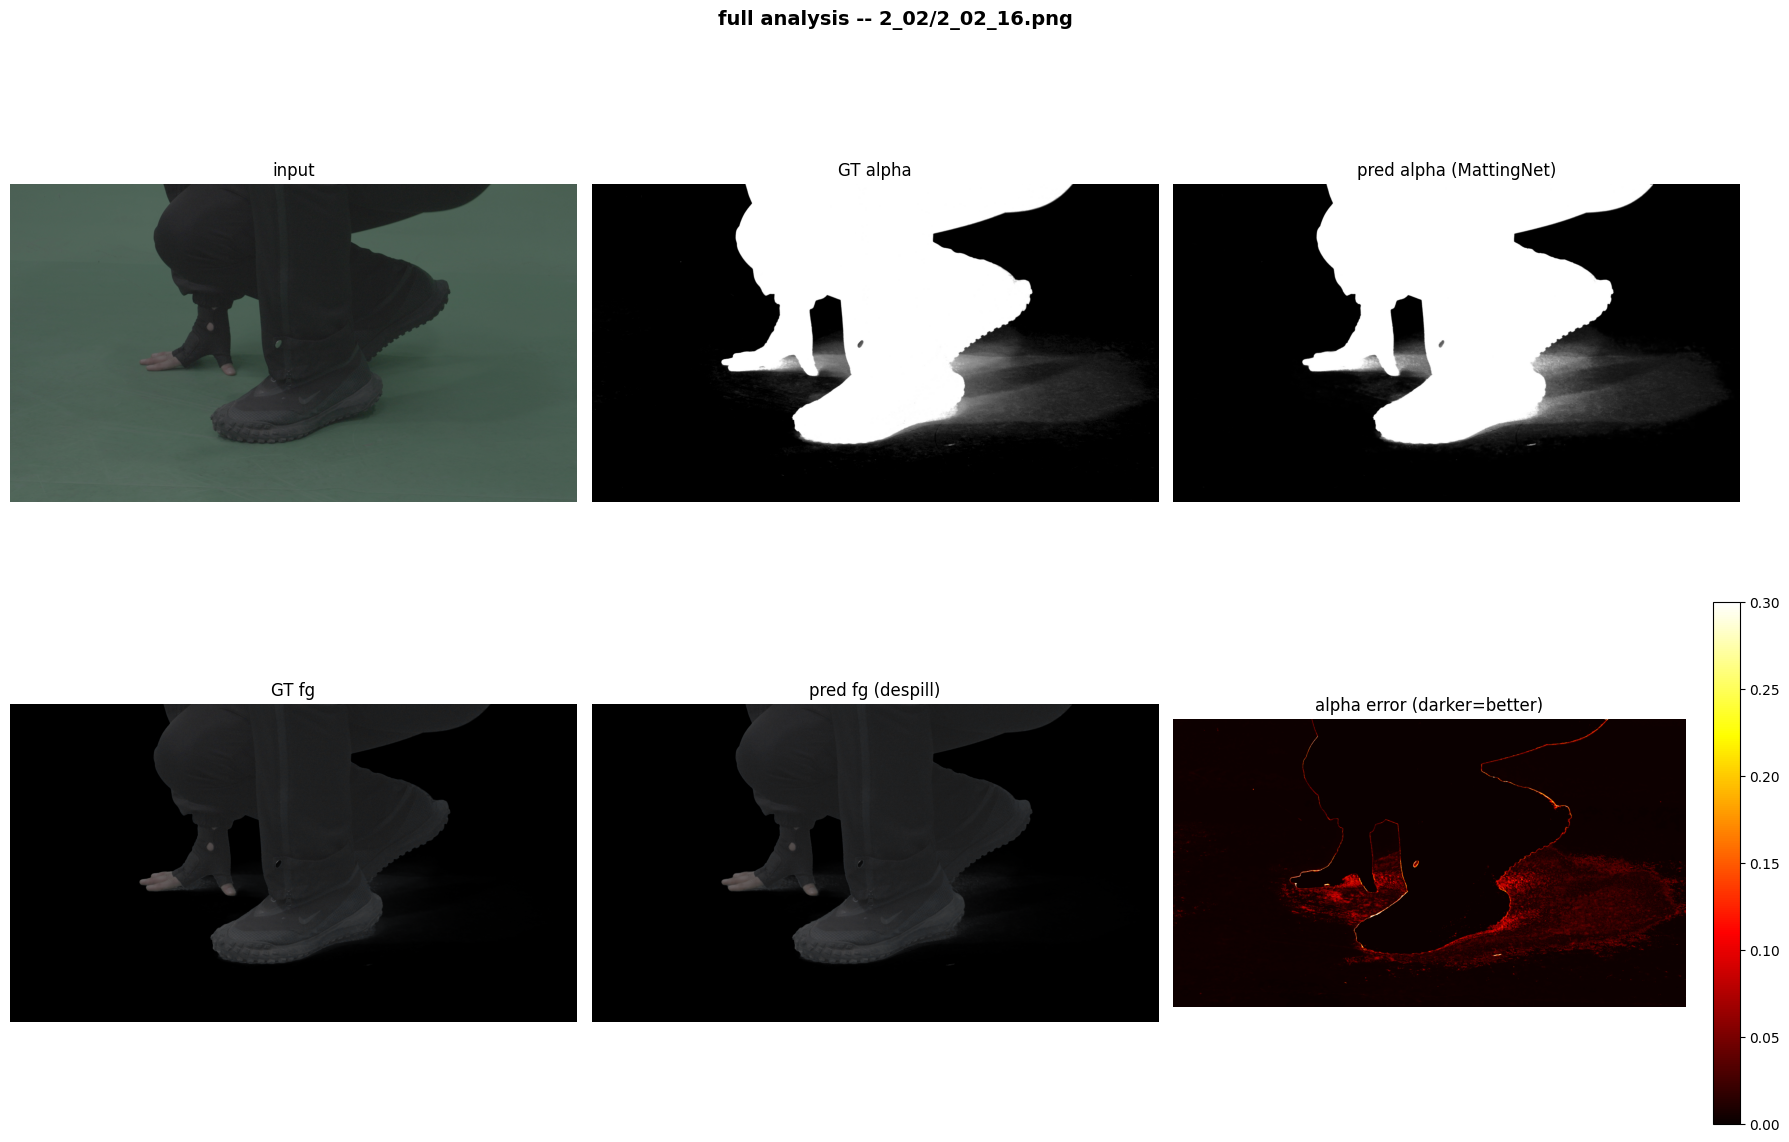

In [13]:
fname = random.choice(sorted(os.listdir(os.path.join(IMAGE_PATH, FOLDER))))

img_np, fg_gt_np, alpha_gt_np, alpha_pred_np, fg_pred_np = predict_new(FOLDER, fname)
a_pred_3ch = alpha_pred_np[:, :, np.newaxis]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle(f'full analysis -- {FOLDER}/{fname}', fontsize=14, fontweight='bold')

axes[0,0].imshow(np.clip(img_np, 0, 1));           axes[0,0].set_title('input')
axes[0,1].imshow(alpha_gt_np,   cmap='gray');       axes[0,1].set_title('GT alpha')
axes[0,2].imshow(alpha_pred_np, cmap='gray');       axes[0,2].set_title('pred alpha (MattingNet)')

axes[1,0].imshow(np.clip(fg_gt_np * alpha_gt_np[:,:,np.newaxis], 0, 1))
axes[1,0].set_title('GT fg')

axes[1,1].imshow(np.clip(fg_pred_np * a_pred_3ch, 0, 1))
axes[1,1].set_title('pred fg (despill)')

# alpha error map
alpha_gt_t = to_tensor(Image.open(os.path.join(FG_PATH, FOLDER, fname)).convert('RGBA').split()[3]).squeeze().numpy()
err_map = np.abs(alpha_pred_np - alpha_gt_t)
im = axes[1,2].imshow(err_map, cmap='hot', vmin=0, vmax=0.3)
axes[1,2].set_title('alpha error (darker=better)')
plt.colorbar(im, ax=axes[1,2], fraction=0.046)

for ax in axes.flat:
    ax.axis('off')
plt.tight_layout()


plt.show()
